# Employee Attrition Prediction with Random Forest

## Problem Overview
This notebook builds a **Random Forest classifier** to predict whether an employee is likely to leave the company (`Attrition = 1`) or stay (`Attrition = 0`).

## Random Forest Algorithm
Random Forest is an **ensemble learning algorithm** that combines many decision trees instead of using only one tree.

### How it works
- The algorithm creates many decision trees from different random samples of the training data.
- Each tree learns a slightly different pattern from the data.
- For classification, every tree gives a vote.
- The final prediction is the class that gets the **most votes**.

### Why it is useful for this project
- It works well for **tabular employee data**.
- It can learn **non-linear relationships** between employee features and attrition.
- It reduces overfitting better than a single decision tree.
- It provides **feature importance**, which helps explain which factors influence attrition more strongly.

## Evaluation Metric Selection
For employee attrition prediction, the **main evaluation metric** in this notebook is **F1 score**.

### Main metric: F1 score
F1 score is used as the main metric because it gives a balanced view of:
- **Precision**: how many predicted attrition cases are actually correct
- **Recall**: how many real attrition cases the model successfully finds

This is important because attrition prediction usually has **class imbalance**, where employees who stay are much more common than employees who leave.

### Supporting metrics
The notebook also reports other metrics to give a fuller evaluation:
- **Accuracy**: overall percentage of correct predictions
- **Precision**: reliability of positive attrition predictions
- **Recall**: ability to detect actual attrition cases
- **ROC-AUC**: overall class-separation ability across thresholds
- **PR-AUC**: useful when the positive class is less common

## Notebook Structure
1. Import libraries
2. Load SMOTE-balanced training data and original test data
3. Explore data distributions and feature relationships
4. Train a baseline Random Forest model
5. Tune the model using GridSearchCV
6. Evaluate the tuned model
7. Tune the prediction threshold
8. Save the final model and CSV outputs in organized folders


## Step 1 — Import Libraries

This section imports all Python libraries used for data handling, modeling, evaluation, plotting, and saving files.


In [27]:
# Data handling
import os
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Model saving
import joblib

# Machine learning model
from sklearn.ensemble import RandomForestClassifier

# Model selection tools
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve
)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries imported successfully')
print('Random state:', RANDOM_STATE)


# Better plot appearance for the notebook
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 11


Libraries imported successfully
Random state: 42


## Step 2 — Load Data

These files come from the preprocessing notebook.

- `X_train_smote.csv`: training features after SMOTE
- `y_train_smote.csv`: training labels after SMOTE
- `X_test.csv`: original test features
- `y_test.csv`: original test labels

> **Important:** SMOTE is used only on the training set. The test set stays unchanged so model evaluation is more realistic.


In [28]:
# Load the balanced training set
X_train = pd.read_csv('../../outputs/X_train_smote.csv')
y_train = pd.read_csv('../../outputs/y_train_smote.csv').values.ravel()

# Load the original test set
X_test = pd.read_csv('../../outputs/X_test.csv')
y_test = pd.read_csv('../../outputs/y_test.csv').values.ravel()

print('Data loaded successfully')
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test shape :', X_test.shape)
print('y_test shape :', y_test.shape)

print('Training class distribution (after SMOTE):')
print(pd.Series(y_train).value_counts().rename({0: 'No Attrition', 1: 'Attrition'}))

print('Test class distribution (original):')
print(pd.Series(y_test).value_counts().rename({0: 'No Attrition', 1: 'Attrition'}))

Data loaded successfully
X_train shape: (1972, 44)
y_train shape: (1972,)
X_test shape : (294, 44)
y_test shape : (294,)
Training class distribution (after SMOTE):
No Attrition    986
Attrition       986
Name: count, dtype: int64
Test class distribution (original):
No Attrition    247
Attrition        47
Name: count, dtype: int64


## Step 3 — Create Output Folders

To keep the project clean, outputs are saved into separate folders.

- `models/` for trained model files
- `predictions/` for prediction-related CSV files
- `metrics/` for metric tables and feature importance CSV files
- `plots/` for saved charts


In [29]:
# Create organized output folders
OUTPUT_DIR = '../../outputs'
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, 'predictions')
METRICS_DIR = os.path.join(OUTPUT_DIR, 'metrics')
PLOTS_DIR = os.path.join(OUTPUT_DIR, 'plots')

for folder in [MODELS_DIR, PREDICTIONS_DIR, METRICS_DIR, PLOTS_DIR]:
    os.makedirs(folder, exist_ok=True)

print('Output folders are ready:')
print(' -', MODELS_DIR)
print(' -', PREDICTIONS_DIR)
print(' -', METRICS_DIR)
print(' -', PLOTS_DIR)


Output folders are ready:
 - ../../outputs\models
 - ../../outputs\predictions
 - ../../outputs\metrics
 - ../../outputs\plots


## Step 4 — Dataset Distribution, Variance, and Relationship Charts

Before training the model, it is useful to look at the data.

This section answers simple questions such as:
- Which numeric features vary the most?
- Which features are strongly related to each other?
- Do training and test distributions look similar?

These checks help us understand the data before modeling.


Top 10 features by variance:
           Feature     Variance
       MonthlyRate 5.048418e+07
     MonthlyIncome 1.832952e+07
         DailyRate 1.457776e+05
        HourlyRate 3.559406e+02
               Age 8.081538e+01
  DistanceFromHome 5.729388e+01
 TotalWorkingYears 5.478533e+01
    YearsAtCompany 3.109401e+01
 PercentSalaryHike 1.211127e+01
YearsInCurrentRole 1.115801e+01


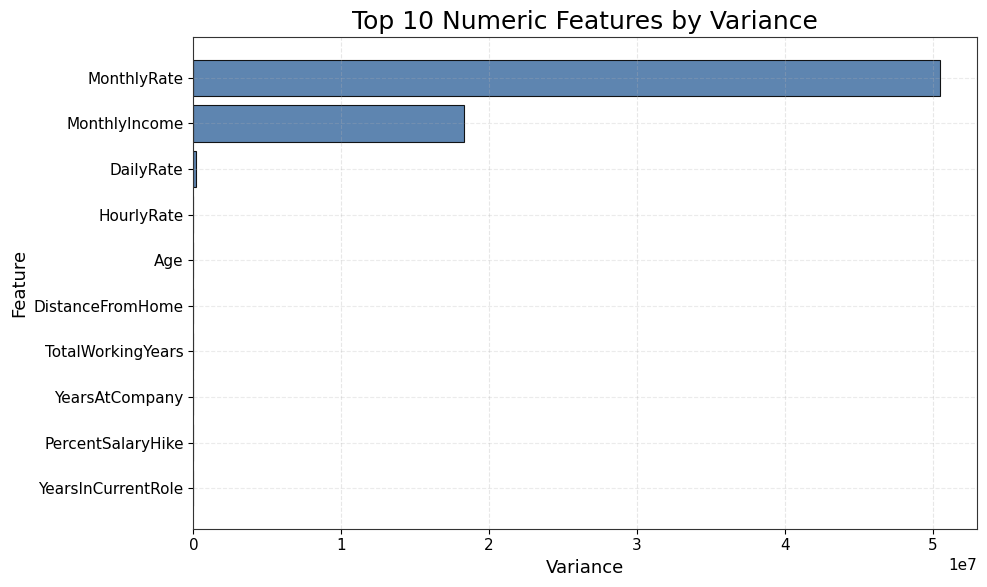

In [30]:
# Keep only numeric columns for variance and correlation analysis
numeric_columns = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Calculate feature variance and rank from highest to lowest
variance_df = (
    X_train[numeric_columns]
    .var()
    .sort_values(ascending=False)
    .reset_index()
)
variance_df.columns = ['Feature', 'Variance']

print('Top 10 features by variance:')
print(variance_df.head(10).to_string(index=False))

# Plot the top 10 variance values
top_variance = variance_df.head(10).iloc[::-1]

plt.figure(figsize=(10, 6))
plt.barh(
    top_variance['Feature'],
    top_variance['Variance'],
    color='#4C78A8',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)
plt.xlabel('Variance')
plt.ylabel('Feature')
plt.title('Top 10 Numeric Features by Variance')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_top_feature_variance.png'), dpi=300, bbox_inches='tight')
plt.show()


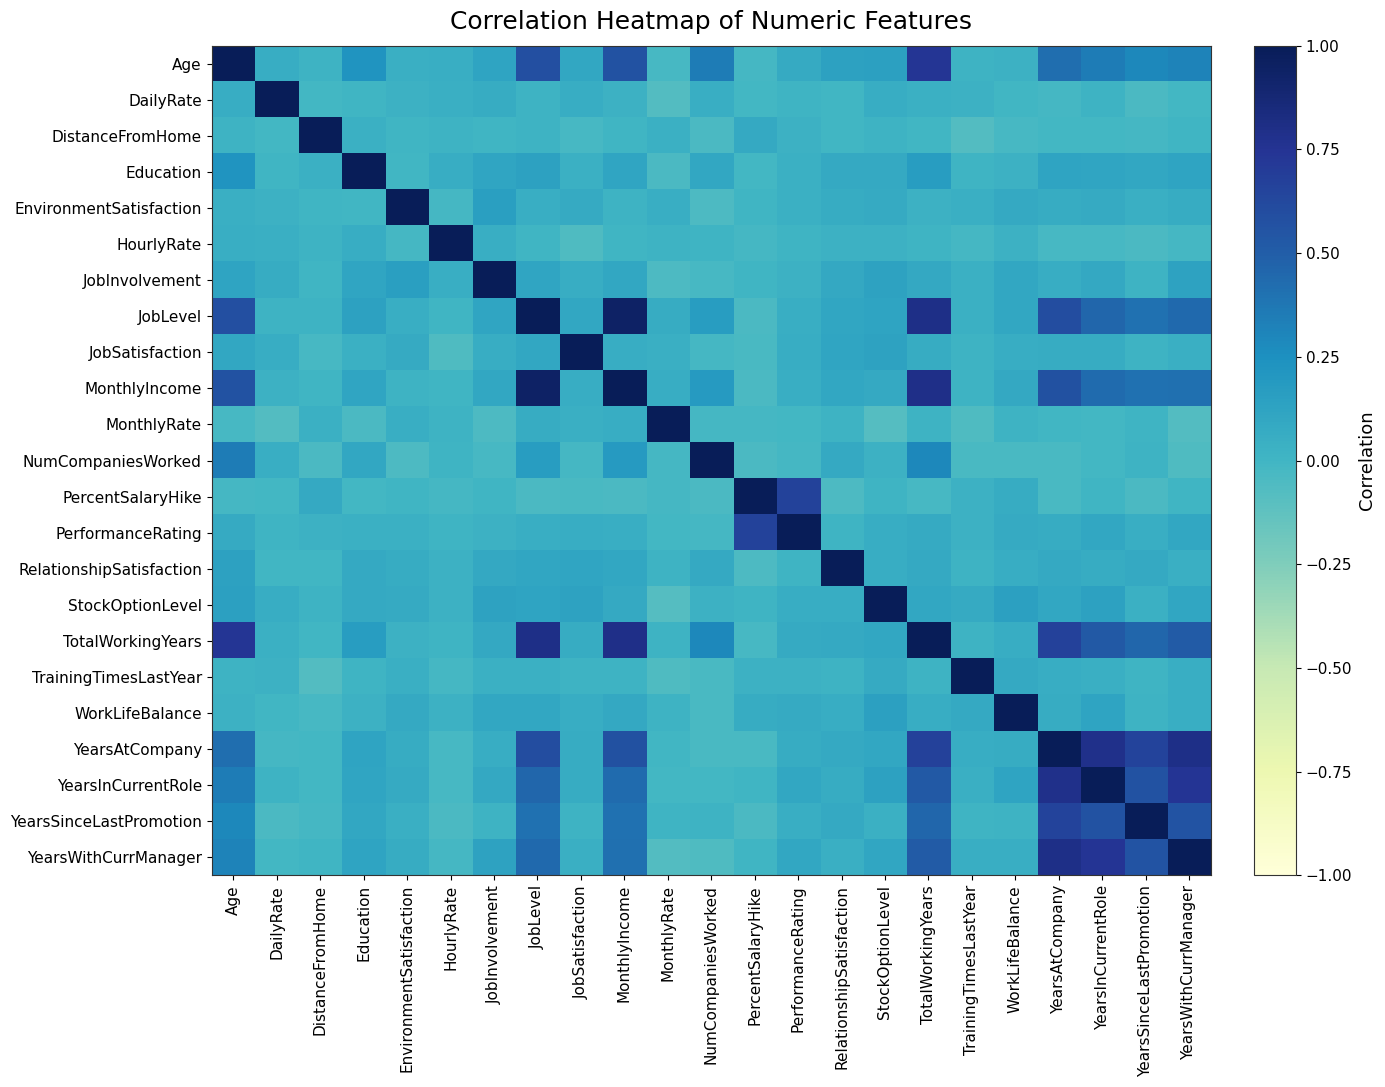

In [31]:
# Compute the correlation matrix for numeric features
correlation_matrix = X_train[numeric_columns].corr()

# Plot a cleaner and more readable correlation heatmap
plt.figure(figsize=(14, 11))
heatmap = plt.imshow(
    correlation_matrix,
    cmap='YlGnBu',
    aspect='auto',
    vmin=-1,
    vmax=1,
    interpolation='nearest'
)

cbar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)
cbar.set_label('Correlation')

plt.xticks(range(len(numeric_columns)), numeric_columns, rotation=90)
plt.yticks(range(len(numeric_columns)), numeric_columns)
plt.title('Correlation Heatmap of Numeric Features', pad=12)
plt.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'rf_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()


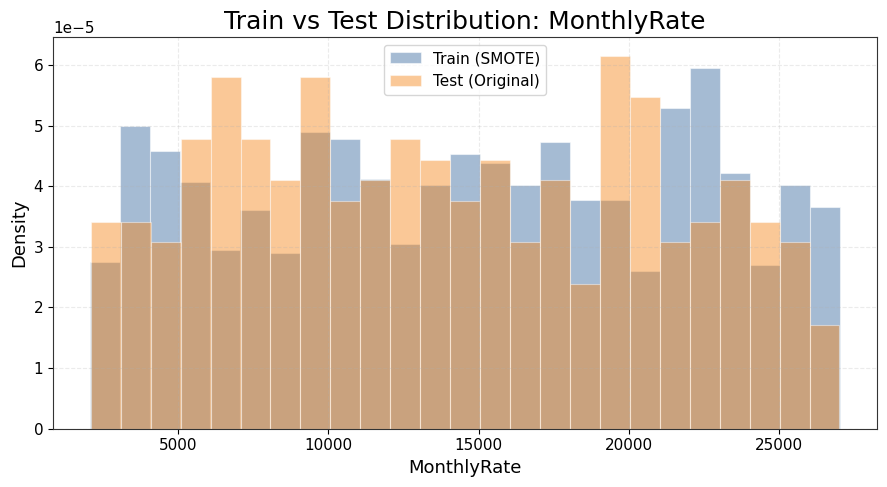

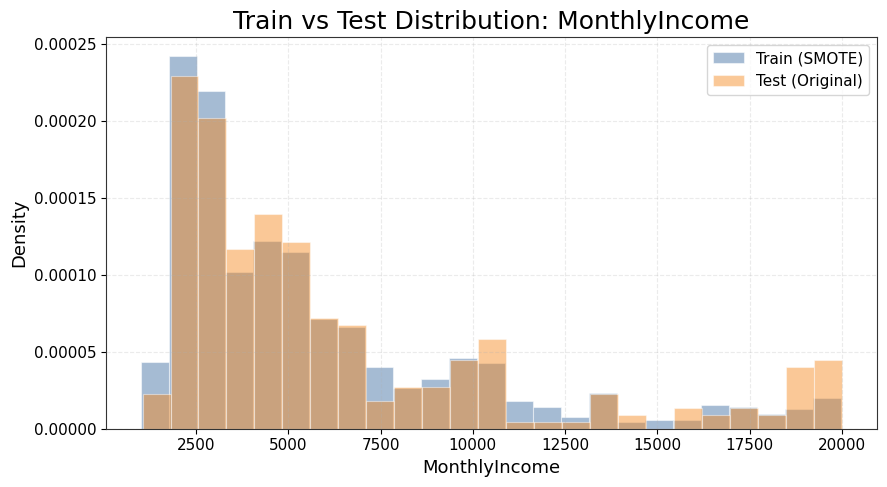

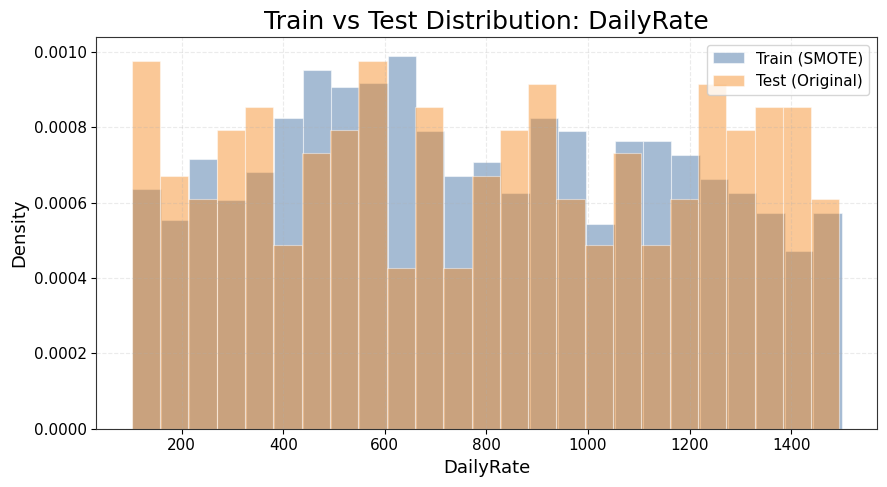

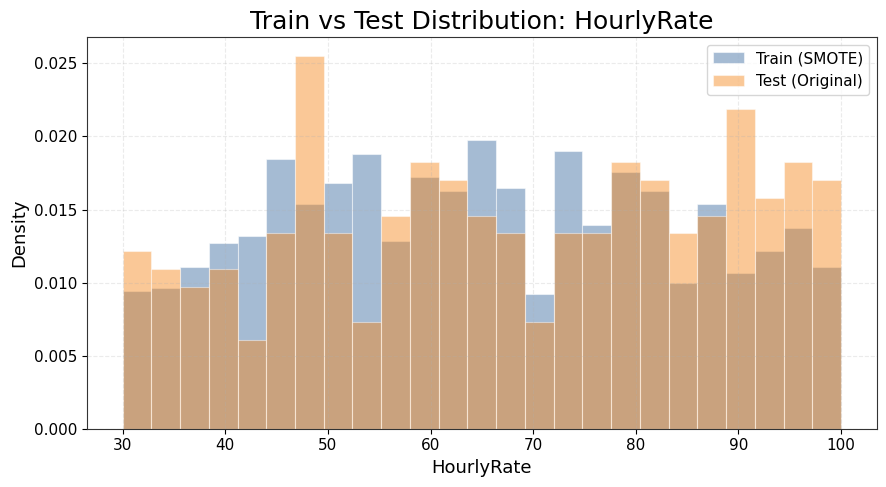

In [32]:
# Compare train and test distributions for top numeric features by variance
# We use the original test set and the SMOTE training set to see whether the shapes are reasonably similar.
top_numeric_features = variance_df.head(4)['Feature'].tolist()

for feature in top_numeric_features:
    plt.figure(figsize=(9, 5))

    plt.hist(
        X_train[feature],
        bins=25,
        density=True,
        alpha=0.50,
        label='Train (SMOTE)',
        color='#4C78A8',
        edgecolor='white',
        linewidth=0.8
    )

    plt.hist(
        X_test[feature],
        bins=25,
        density=True,
        alpha=0.45,
        label='Test (Original)',
        color='#F58518',
        edgecolor='white',
        linewidth=0.8
    )

    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.title(f'Train vs Test Distribution: {feature}')
    plt.legend(frameon=True)
    plt.grid(axis='y', linestyle='--', alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f'rf_distribution_{feature}.png'), dpi=300, bbox_inches='tight')
    plt.show()


## Step 5 — Train a Baseline Model

A baseline model is a simple starting point. It helps us see whether hyperparameter tuning really improves the results.


In [33]:
# Train a default Random Forest model for comparison
baseline_rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
baseline_rf.fit(X_train, y_train)

# Make baseline predictions
baseline_pred = baseline_rf.predict(X_test)
baseline_prob = baseline_rf.predict_proba(X_test)[:, 1]

# Evaluate the baseline model
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, baseline_pred),
    'F1 Score': f1_score(y_test, baseline_pred, zero_division=0),
    'Precision': precision_score(y_test, baseline_pred, zero_division=0),
    'Recall': recall_score(y_test, baseline_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, baseline_prob),
    'PR-AUC': average_precision_score(y_test, baseline_prob)
}

print('Baseline model results:')
for metric, value in baseline_metrics.items():
    print(f'  {metric:10s}: {value:.4f}')


Baseline model results:
  Accuracy  : 0.8231
  F1 Score  : 0.2778
  Precision : 0.4000
  Recall    : 0.2128
  ROC-AUC   : 0.7383
  PR-AUC    : 0.3675


## Step 6 — Define the Hyperparameter Grid

GridSearchCV will try different parameter combinations and find the best one.

### Simple meaning of each parameter
- `n_estimators`: number of trees
- `max_depth`: maximum depth of each tree
- `min_samples_split`: minimum samples needed to split a node
- `min_samples_leaf`: minimum samples allowed in a leaf
- `max_features`: number of features considered at each split
- `class_weight`: gives more importance to minority class when needed


In [34]:
# Define values to test during hyperparameter tuning
param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'class_weight': [None, 'balanced']
}

# Count how many combinations will be tested
combination_count = 1
for values in param_grid.values():
    combination_count *= len(values)

print('Parameter grid created')
print('Total combinations:', combination_count)
print('Total fits with 5-fold CV:', combination_count * 5)


Parameter grid created
Total combinations: 144
Total fits with 5-fold CV: 720


## Step 7 — Create the Base Random Forest Model

This model is the starting estimator that GridSearchCV will tune.


In [35]:
# Create the base Random Forest model
rf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Base Random Forest model created')


Base Random Forest model created


## Step 8 — Run GridSearchCV

### Why use StratifiedKFold?
It keeps the class ratio similar in every fold.

### Why use F1 as the scoring metric?
Because this problem is about finding attrition cases well, not only getting high overall accuracy.


In [36]:
# Create stratified cross-validation folds
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Train all parameter combinations and keep the best model
grid_search.fit(X_train, y_train)

print('Grid search completed')
print('Best parameters:', grid_search.best_params_)
print('Best cross-validation F1 score:', round(grid_search.best_score_, 4))


Fitting 5 folds for each of 144 candidates, totalling 720 fits
Grid search completed
Best parameters: {'class_weight': 'balanced', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validation F1 score: 0.9266


## Step 9 — Select the Best Tuned Model

After GridSearchCV finishes, the best model is already retrained on the full training set.


In [37]:
# Get the best tuned model
best_rf = grid_search.best_estimator_

print('Best tuned model selected:')
print(best_rf)


Best tuned model selected:
RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=300,
                       n_jobs=-1, random_state=42)


## Step 10 — Make Predictions with the Tuned Model

We create both:
- class predictions (`0` or `1`)
- probability predictions (used for threshold tuning and AUC metrics)


In [38]:
# Predict classes using the default 0.50 threshold
y_pred = best_rf.predict(X_test)

# Predict probabilities for the positive class (Attrition = 1)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print('Predictions created successfully')
print('Predicted attrition cases at threshold 0.50:', int(y_pred.sum()))


Predictions created successfully
Predicted attrition cases at threshold 0.50: 30


## Step 11 — Evaluate Baseline vs Tuned Model

This comparison shows whether hyperparameter tuning improved the model.


In [39]:
# Calculate tuned model metrics
tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'F1 Score': f1_score(y_test, y_pred, zero_division=0),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_prob),
    'PR-AUC': average_precision_score(y_test, y_prob)
}

# Compare baseline and tuned model results
comparison_df = pd.DataFrame({
    'Baseline (Default RF)': baseline_metrics,
    'Tuned (GridSearchCV)': tuned_metrics
})
comparison_df['Improvement'] = comparison_df['Tuned (GridSearchCV)'] - comparison_df['Baseline (Default RF)']

print('Model performance comparison:')
print(comparison_df.round(4).to_string())

print('Classification report for tuned model:')
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition'], zero_division=0))


Model performance comparison:
           Baseline (Default RF)  Tuned (GridSearchCV)  Improvement
Accuracy                  0.8231                0.8333       0.0102
F1 Score                  0.2778                0.3636       0.0859
Precision                 0.4000                0.4667       0.0667
Recall                    0.2128                0.2979       0.0851
ROC-AUC                   0.7383                0.7495       0.0112
PR-AUC                    0.3675                0.3704       0.0029
Classification report for tuned model:
              precision    recall  f1-score   support

No Attrition       0.88      0.94      0.90       247
   Attrition       0.47      0.30      0.36        47

    accuracy                           0.83       294
   macro avg       0.67      0.62      0.63       294
weighted avg       0.81      0.83      0.82       294

